In [102]:
import torch
import pandas as pd
import numpy as np
import sklearn.metrics as metric
from sklearn.preprocessing import RobustScaler
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [103]:
from data_load import scaled_data, raw_data, result, data_info

In [104]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [105]:
raw_data.describe()

,idx,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
count,11939.000000,11939,1.193900e+04,1.193900e+04,11939.000000,11939.000000,11939.000000,11939.000000
mean,732.280761,2020-03-29 10:49:44.571572,7.000000e-01,7.000000e-01,2.787925,14.711208,2.704223,71.724123
min,1.000000,2020-03-24 00:00:00,7.000000e-01,7.000000e-01,1.740000,14.520000,2.464000,70.000000
25%,332.000000,2020-03-26 00:00:00,7.000000e-01,7.000000e-01,2.310000,14.610000,2.699000,71.000000
50%,664.000000,2020-03-30 00:00:00,7.000000e-01,7.000000e-01,2.340000,14.730000,2.702000,72.000000
75%,1081.000000,2020-04-02 00:00:00,7.000000e-01,7.000000e-01,2.370000,14.750000,2.706000,72.000000
max,2000.000000,2020-04-07 00:00:00,7.000000e-01,7.000000e-01,10.540000,15.070000,2.861000,73.000000
std,481.996313,NaN,1.110270e-16,1.110270e-16,1.455966,0.099000,0.024700,0.632049


In [106]:
labels_to_drop = ['idx', 'Machine_Name', 'Item No', 'working time', 'Thickness 1(mm)', 'Thickness 2(mm)']

df = raw_data.drop(columns=labels_to_drop, errors='ignore')

df['Energy'] = df['weld current(kA)'] * df['weld Voltage(v)'] * df['weld time(ms)']
df['Resistance'] = df['weld Voltage(v)'] / df['weld current(kA)']
df['Force-Current Dynamics'] = df['weld current(kA)'] / df['weld force(bar)']
df['Power to Force Ratio'] = df['weld Voltage(v)'] * df['weld current(kA)'] / df['weld force(bar)']

split_index = int(len(df) * 0.8)

df_train = df.iloc[:split_index]
df_test = df.iloc[split_index:]

print(f"Size of train dataset: {df_train.shape}")
print(f"Size of test dataset: {df_test.shape}")

df.corr()

Size of train dataset: (9551, 8)
Size of test dataset: (2388, 8)


,weld force(bar),weld current(kA),weld Voltage(v),weld time(ms),Energy,Resistance,Force-Current Dynamics,Power to Force Ratio
weld force(bar),1.000000,0.411675,0.133876,-0.005557,0.265580,-0.145538,-0.982329,-0.983688
weld current(kA),0.411675,1.000000,0.129596,-0.020933,0.519101,-0.524082,-0.382536,-0.381570
weld Voltage(v),0.133876,0.129596,1.000000,0.010169,0.680115,0.776538,-0.207480,-0.188520
weld time(ms),-0.005557,-0.020933,0.010169,1.000000,0.587309,0.021984,0.003027,0.003148
Energy,0.265580,0.519101,0.680115,0.587309,1.000000,0.254268,-0.299174,-0.287001
Resistance,-0.145538,-0.524082,0.776538,0.021984,0.254268,1.000000,0.063587,0.079262
Force-Current Dynamics,-0.982329,-0.382536,-0.207480,0.003027,-0.299174,0.063587,1.000000,0.999754
Power to Force Ratio,-0.983688,-0.381570,-0.188520,0.003148,-0.287001,0.079262,0.999754,1.000000


In [107]:
scaler = RobustScaler()

train_scaled = scaler.fit_transform(df_train)
test_scaled = scaler.transform(df_test)

df_train_scaled = pd.DataFrame(train_scaled, columns=df_train.columns, index=df_train.index)
df_test_scaled = pd.DataFrame(test_scaled, columns=df_test.columns, index=df_test.index)

print(df_train_scaled.head())

   weld force(bar)  weld current(kA)  weld Voltage(v)  weld time(ms)  \
0        -0.166667         -1.142857        -0.142857            0.0   
1         0.333333         -1.142857        -0.142857            0.0   
2         0.500000         -1.357143         0.142857           -1.0   
3         0.500000         -1.357143         0.142857            0.0   
4         0.333333         -1.214286         0.285714            0.0   

     Energy  Resistance  Force-Current Dynamics  Power to Force Ratio  
0 -0.457025    0.903489               -0.104024             -0.115373  
1 -0.457025    0.903489               -0.457747             -0.466913  
2 -1.506360    1.173196               -0.629992             -0.618005  
3 -0.548213    1.173196               -0.629992             -0.618005  
4 -0.427764    1.076381               -0.476602             -0.455348  


In [108]:
input_dim = df_train_scaled.shape[1]

X_train_tensor = torch.FloatTensor(df_train_scaled.values)
X_test_tensor = torch.FloatTensor(df_test_scaled.values)

batch_size = 64
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [109]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        # 인코더 (입력 -> 압축)
        # 예시로 차원을 점진적으로 줄여 잠재 공간(Latent space)을 구성합니다.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, 2),
            nn.ReLU(),
            nn.Linear(2, 1)  # 가장 압축된 병목 구간 (차원은 데이터에 맞게 조절 가능)
        )
        
        # 디코더 (압축 -> 복원)
        # 인코더의 역순으로 차원을 다시 늘려 입력 차원과 똑같이 맞춥니다.
        self.decoder = nn.Sequential(
            nn.Linear(1, 2),
            nn.ReLU(),
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, input_dim) # 최종 출력은 입력 차원과 동일
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [110]:
model = Autoencoder(input_dim)

# 3. 손실 함수 및 옵티마이저 설정
# 복원 오차를 측정하기 위해 평균 제곱 오차(MSE)를 사용합니다.
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [111]:
epochs = 200
model.train() # 학습 모드 설정

for epoch in range(epochs):
    epoch_loss = 0
    for batch_x, _ in train_loader:
        # 옵티마이저 초기화
        optimizer.zero_grad()
        
        # 순전파 (Forward pass)
        outputs = model(batch_x)
        
        # 손실(복원 오차) 계산: 입력(batch_x)과 출력(outputs)의 차이
        loss = criterion(outputs, batch_x)
        
        # 역전파 (Backward pass) 및 가중치 업데이트
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        
    # 10 에포크마다 손실값 출력
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss/len(train_loader):.4f}')

Epoch [10/200], Loss: 2.1694
Epoch [20/200], Loss: 2.0058
Epoch [30/200], Loss: 1.9576
Epoch [40/200], Loss: 1.9382
Epoch [50/200], Loss: 1.9267
Epoch [60/200], Loss: 1.8902
Epoch [70/200], Loss: 1.8663
Epoch [80/200], Loss: 1.8363
Epoch [90/200], Loss: 1.8085
Epoch [100/200], Loss: 1.7901
Epoch [110/200], Loss: 1.7549
Epoch [120/200], Loss: 1.7382
Epoch [130/200], Loss: 1.7155
Epoch [140/200], Loss: 1.7052
Epoch [150/200], Loss: 1.6695
Epoch [160/200], Loss: 1.6531
Epoch [170/200], Loss: 1.6324
Epoch [180/200], Loss: 1.6162
Epoch [190/200], Loss: 1.5902
Epoch [200/200], Loss: 1.5770


In [ ]:
model.eval() # 평가 모드 설정 (Dropout, BatchNorm 비활성화)

with torch.no_grad():
    # 테스트 데이터 입력하여 복원 결과 얻기
    reconstructed = model(X_test_tensor)
    
    # 각 샘플별 복원 오차(MSE) 계산
    # dim=1 기준으로 평균을 구하여 샘플마다 하나의 오차값을 가짐
    mse_loss = torch.mean((X_test_tensor - reconstructed) ** 2, dim=1).numpy()

# 결과 분석을 위해 테스트 데이터프레임에 복원 오차 파생변수 추가
df_test_with_loss = df_test_scaled.copy()
df_test_with_loss['Reconstruction_Error'] = mse_loss

# 임계값(Threshold)을 설정하여 이상치 판별
# 예: 훈련 데이터 오차의 분포를 분석하거나, 특정 상위 백분위수(예: 95%)를 임계값으로 지정
threshold = np.percentile(mse_loss, 99.62) 
df_test_with_loss['Is_Anomaly'] = df_test_with_loss['Reconstruction_Error'] > threshold

print(df_test_with_loss['Is_Anomaly'].value_counts())

Is_Anomaly
False    2378
True       10
Name: count, dtype: int64


이상치 유형별 개수
Anomaly_Type
Anomaly Type 1    2
Anomaly Type 2    2
Anomaly Type 3    6
Name: count, dtype: int64


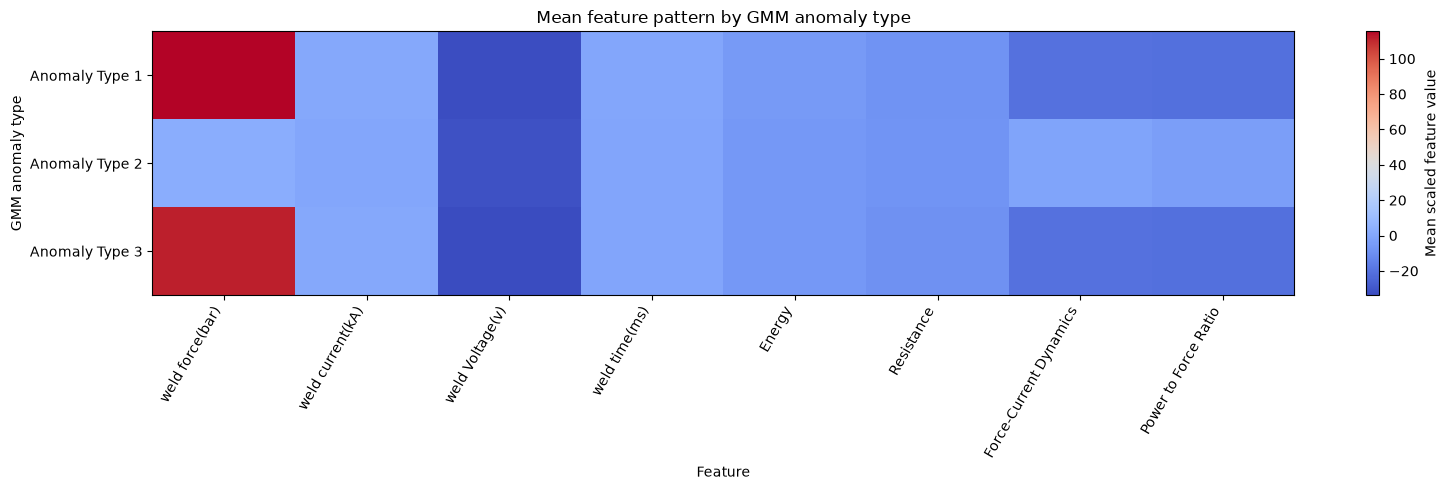

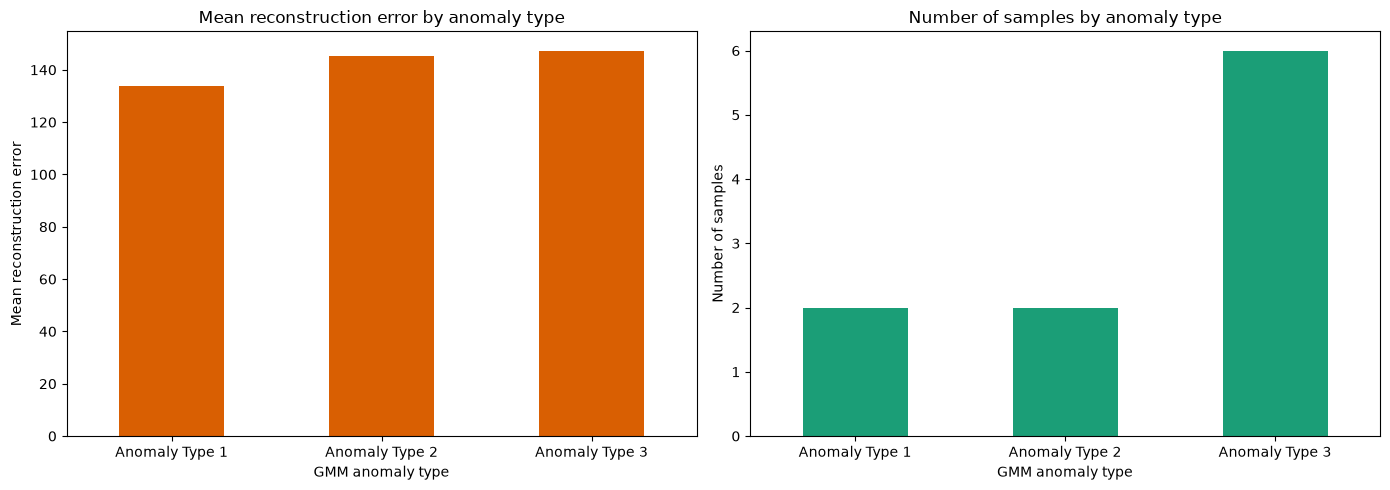

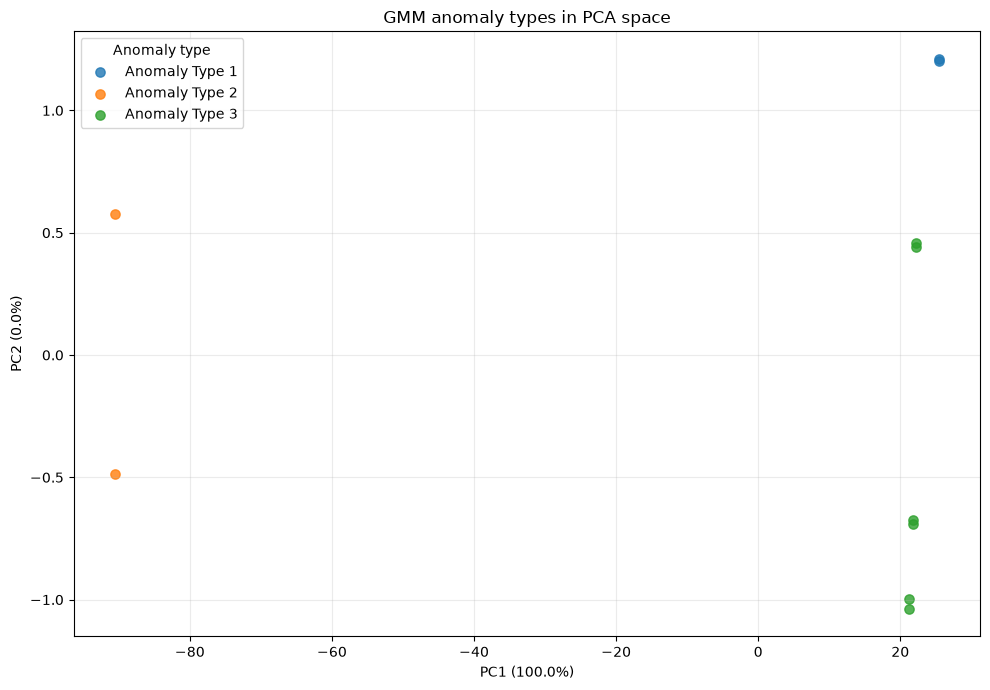

\nAnomaly Type 1 - reconstruction error가 큰 피처


,Mean absolute reconstruction error
weld Voltage(v),23.311277
weld force(bar),6.968159
Resistance,5.468388
Energy,4.011960
Force-Current Dynamics,1.585005


\nAnomaly Type 2 - reconstruction error가 큰 피처


,Mean absolute reconstruction error
weld Voltage(v),31.311237
Resistance,8.424686
Energy,5.280623
Power to Force Ratio,3.349988
weld force(bar),2.187242


\nAnomaly Type 3 - reconstruction error가 큰 피처


,Mean absolute reconstruction error
weld Voltage(v),25.313601
weld force(bar),7.446500
Resistance,6.063738
Energy,4.897407
Force-Current Dynamics,1.482794


In [113]:
# Autoencoder가 탐지한 이상치를 GMM으로 3가지 유형으로 분류
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA

feature_columns = df_test_scaled.columns.tolist()
anomaly_mask = df_test_with_loss['Is_Anomaly'].astype(bool)
anomaly_data = df_test_scaled.loc[anomaly_mask, feature_columns].copy()
anomaly_errors = df_test_with_loss.loc[anomaly_mask, 'Reconstruction_Error'].copy()

if len(anomaly_data) < 3:
    raise ValueError(
        f'GMM 3개 그룹을 만들려면 이상치가 최소 3개 필요합니다. 현재 이상치는 {len(anomaly_data)}개입니다.'
    )

# GMM으로 이상치 피처 패턴을 3개 그룹으로 분류합니다.
gmm = GaussianMixture(
    n_components=3,
    covariance_type='full',
    random_state=42,
    n_init=10
)
gmm_labels = gmm.fit_predict(anomaly_data)
anomaly_data['GMM_Label'] = gmm_labels
anomaly_data['Reconstruction_Error'] = anomaly_errors

# GMM label은 실행마다 의미가 바뀔 수 있으므로 평균 복원오차 순으로 이름을 고정합니다.
label_order = anomaly_data.groupby('GMM_Label')['Reconstruction_Error'].mean().sort_values().index
label_names = {
    label: f'Anomaly Type {rank + 1}'
    for rank, label in enumerate(label_order)
}
anomaly_data['Anomaly_Type'] = anomaly_data['GMM_Label'].map(label_names)

df_test_with_loss['Anomaly_Type'] = 'Normal'
df_test_with_loss.loc[anomaly_data.index, 'Anomaly_Type'] = anomaly_data['Anomaly_Type']

print('이상치 유형별 개수')
print(anomaly_data['Anomaly_Type'].value_counts().sort_index())

# 유형별 평균 피처값을 계산합니다.
type_feature_mean = anomaly_data.groupby('Anomaly_Type')[feature_columns].mean()
type_feature_mean = type_feature_mean.reindex(sorted(type_feature_mean.index))

# 1. 유형별 평균 피처 패턴 히트맵
plt.figure(figsize=(16, 5))
plt.imshow(type_feature_mean, aspect='auto', cmap='coolwarm')
plt.colorbar(label='Mean scaled feature value')
plt.xticks(range(len(feature_columns)), feature_columns, rotation=60, ha='right')
plt.yticks(range(len(type_feature_mean.index)), type_feature_mean.index)
plt.xlabel('Feature')
plt.ylabel('GMM anomaly type')
plt.title('Mean feature pattern by GMM anomaly type')
plt.tight_layout()
plt.show()

# 2. 유형별 평균 복원오차 비교
error_by_type = anomaly_data.groupby('Anomaly_Type')['Reconstruction_Error'].agg(
    ['mean', 'median', 'count']
).reindex(sorted(anomaly_data['Anomaly_Type'].unique()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
error_by_type['mean'].plot(kind='bar', ax=axes[0], color='#d95f02')
axes[0].set_title('Mean reconstruction error by anomaly type')
axes[0].set_xlabel('GMM anomaly type')
axes[0].set_ylabel('Mean reconstruction error')
axes[0].tick_params(axis='x', rotation=0)

error_by_type['count'].plot(kind='bar', ax=axes[1], color='#1b9e77')
axes[1].set_title('Number of samples by anomaly type')
axes[1].set_xlabel('GMM anomaly type')
axes[1].set_ylabel('Number of samples')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 3. PCA 2차원 공간에서 GMM 유형 분포 시각화
pca = PCA(n_components=2, random_state=42)
anomaly_pca = pca.fit_transform(anomaly_data[feature_columns])
pca_df = pd.DataFrame(anomaly_pca, columns=['PC1', 'PC2'], index=anomaly_data.index)
pca_df['Anomaly_Type'] = anomaly_data['Anomaly_Type']
pca_df['Reconstruction_Error'] = anomaly_data['Reconstruction_Error']

plt.figure(figsize=(10, 7))
for anomaly_type, group in pca_df.groupby('Anomaly_Type'):
    plt.scatter(
        group['PC1'],
        group['PC2'],
        s=45,
        alpha=0.8,
        label=anomaly_type
    )
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.title('GMM anomaly types in PCA space')
plt.legend(title='Anomaly type')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# 각 유형에서 복원오차가 큰 피처를 확인합니다.
for anomaly_type in sorted(anomaly_data['Anomaly_Type'].unique()):
    type_indices = anomaly_data.index[anomaly_data['Anomaly_Type'] == anomaly_type]
    mean_errors = error_df.loc[type_indices].mean().sort_values(ascending=False)
    print(f'\\n{anomaly_type} - reconstruction error가 큰 피처')
    display(mean_errors.head(5).to_frame('Mean absolute reconstruction error'))